# Decision Tree and Feature Selection

## Introduction

Previous experiments investigated how data quality affects machine learning performance.

In this experiment, the focus is on feature selection and its influence on a Decision Tree classifier.

Three different feature sets will be compared:

- Basic Features
- Extended Features
- All Features

The objective is to determine whether adding or removing features changes the performance of the Decision Tree model.

## Import Libraries

The following libraries are used for data preprocessing, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay)

import matplotlib.pyplot as plt

## Load the Dataset

The Titanic dataset used in the previous experiments is loaded again to ensure that the same dataset is used for the feature selection experiment.

The dataset will then be prepared using the same preprocessing approach as in the previous experiments.

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")


## Data Preprocessing

The dataset is prepared using the same preprocessing procedure used in the previous experiments.

Missing values in Age and Embarked are handled, categorical variables are converted into numerical values, and unnecessary columns are removed.

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df, columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])


## Feature Selection

Three different feature sets are created to investigate how the choice of input features affects Decision Tree performance.

Basic Features contain the main passenger characteristics.

Extended Features include additional information that may provide useful predictive patterns.

All Features contain all available processed features in the dataset.

In [9]:
basic_features = ["Pclass", "Age", "SibSp","Parch","Fare"]
extended_features = ["Pclass", "Age","SibSp", "Parch", "Fare","Sex_male"]

all_features = [column for column in df.columns
if column != "Survived"]

feature_sets = {"Basic Features": basic_features, "Extended Features": extended_features,"All Features": all_features}

## Train and Evaluate Decision Tree

A separate Decision Tree classifier is trained for each feature set.

The same train-test split and random state are used for all experiments to ensure a fair comparison.

Accuracy, Precision, Recall, F1-score, and confusion matrix values are calculated for each feature configuration.

In [10]:
results = []

for name, features in feature_sets.items():

    X = df[features]
    y = df["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42)

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix( y_test,y_pred).ravel()

    results.append({
        "Feature Set": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp})

## Results

The evaluation results for each feature configuration are combined into a single table.

The table allows the performance of the Decision Tree model to be compared across the three feature sets.

In [11]:
comparison = pd.DataFrame(results)

comparison = comparison.round(3)

comparison

,Feature Set,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,Basic Features,0.631,0.562,0.486,0.522,77,28,38,36
1,Extended Features,0.749,0.693,0.703,0.698,82,23,22,52
2,All Features,0.782,0.727,0.757,0.742,84,21,18,56


## Accuracy Comparison

The following graph compares the Accuracy of the Decision Tree model across the three feature sets.

This visualization shows how the overall classification performance changes when additional features are included.

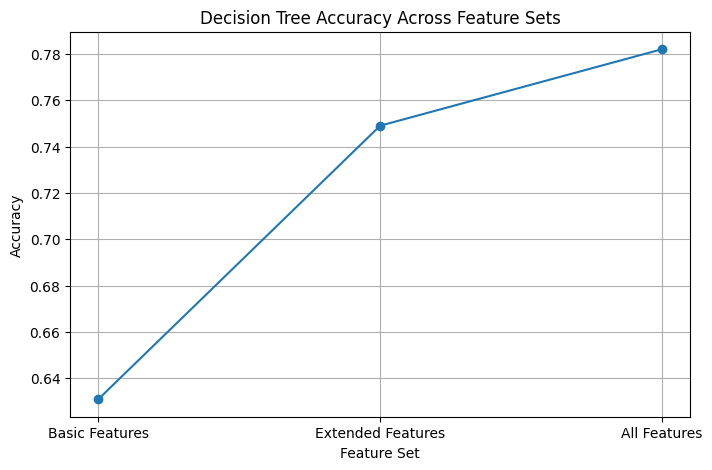

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(comparison["Feature Set"], comparison["Accuracy"], marker="o")

plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy Across Feature Sets")

plt.grid(True)


plt.show()

## F1-score Comparison

The following graph compares the F1-score of the Decision Tree model across the three feature sets.

The F1-score is used to evaluate the balance between Precision and Recall and provides an additional measure of classification performance.

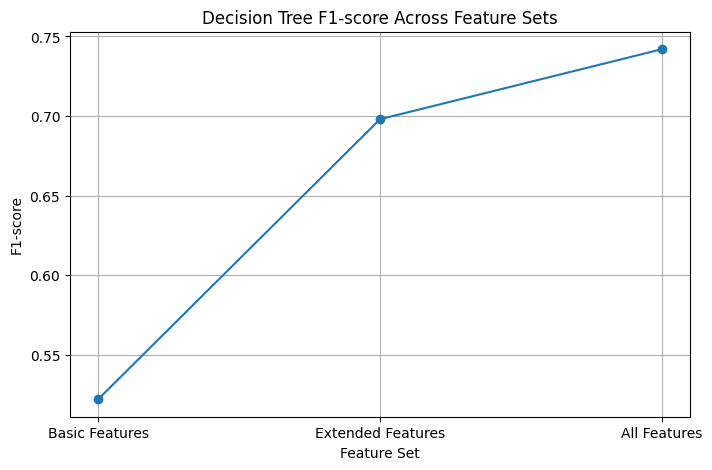

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(comparison["Feature Set"],comparison["F1-score"],marker="o")

plt.xlabel("Feature Set")
plt.ylabel("F1-score")
plt.title("Decision Tree F1-score Across Feature Sets")

plt.grid(True)

plt.show()